In [1]:
# Cell 1 — Imports

import numpy as np
import matplotlib.pyplot as plt

from iqwav.modulation import generate_real_tone, generate_iq_tone

In [2]:
# Cell 2 — Generate a real tone

fs = 1000
freq = 10
duration = 1.0
amplitude = 1.0
phase = 0.0

t, real = generate_real_tone(
    fs=fs,
    freq=freq,
    duration=duration,
    amplitude=amplitude,
    phase=phase,
)

print("Samples:", len(real))
print("First 10 samples:")
print(real[:10])

Samples: 1000
First 10 samples:
[1.         0.99802673 0.9921147  0.98228725 0.96858316 0.95105652
 0.92977649 0.90482705 0.87630668 0.84432793]


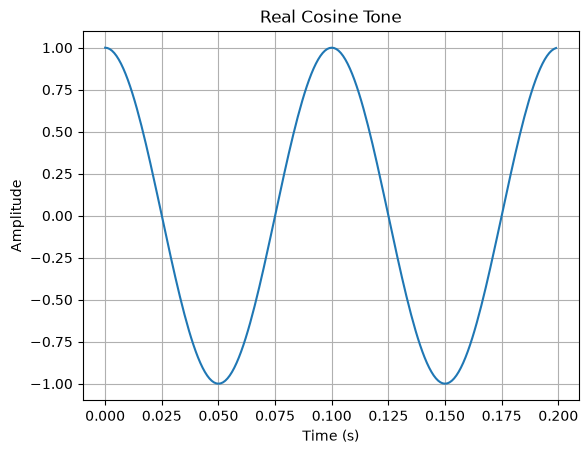

In [3]:
# Cell 3 — Plot real tone

plt.plot(t[:200], real[:200])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Real Cosine Tone")
plt.grid()
plt.show()

In [4]:
# Cell 4 — Generate IQ tone

_, iq = generate_iq_tone(
    fs=fs,
    freq=freq,
    duration=duration,
    amplitude=1.0,
    phase=0.0,
)

print("First 10 IQ samples:")
print(iq[:10])

First 10 IQ samples:
[1.        +0.j         0.99802673+0.06279052j 0.9921147 +0.12533323j
 0.98228725+0.18738131j 0.96858316+0.24868989j 0.95105652+0.30901699j
 0.92977649+0.36812455j 0.90482705+0.42577929j 0.87630668+0.48175367j
 0.84432793+0.53582679j]


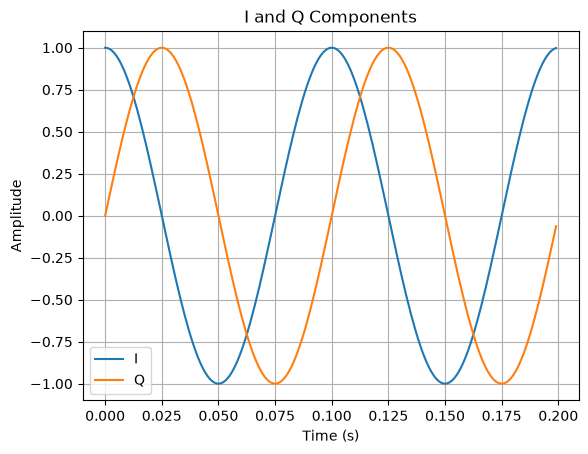

In [5]:
# Cell 5 — Plot I and Q versus time

plt.plot(t[:200], iq.real[:200], label="I")
plt.plot(t[:200], iq.imag[:200], label="Q")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("I and Q Components")
plt.legend()
plt.grid()
plt.show()

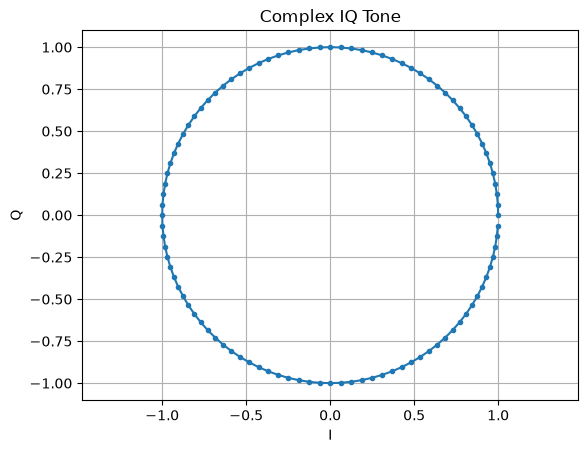

In [6]:
# Cell 6 — IQ plane

plt.plot(iq.real[:100], iq.imag[:100], ".-")
plt.xlabel("I")
plt.ylabel("Q")
plt.title("Complex IQ Tone")
plt.axis("equal")
plt.grid()
plt.show()

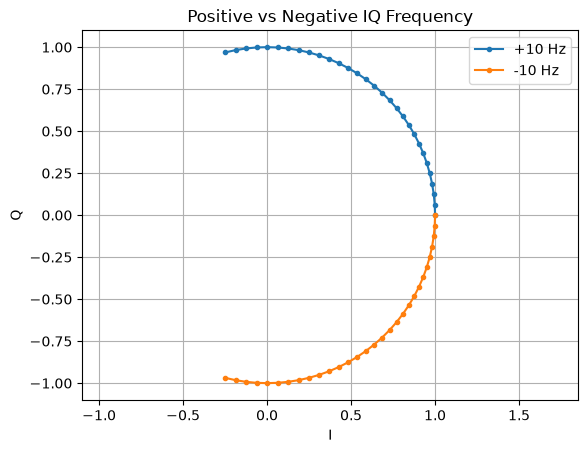

In [7]:
# Cell 7 — Positive vs negative frequency

_, iq_pos = generate_iq_tone(fs=1000, freq=10, duration=0.1)
_, iq_neg = generate_iq_tone(fs=1000, freq=-10, duration=0.1)

plt.plot(iq_pos.real[:30], iq_pos.imag[:30], ".-", label="+10 Hz")
plt.plot(iq_neg.real[:30], iq_neg.imag[:30], ".-", label="-10 Hz")

plt.xlabel("I")
plt.ylabel("Q")
plt.title("Positive vs Negative IQ Frequency")
plt.axis("equal")
plt.legend()
plt.grid()
plt.show()

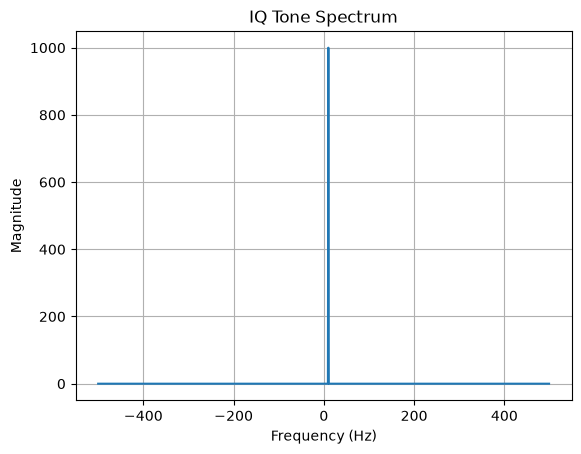

In [8]:
from iqwav.dsp import magnitude_spectrum

freqs, mag = magnitude_spectrum(iq, fs)

plt.plot(freqs, mag)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("IQ Tone Spectrum")
plt.grid()
plt.show()

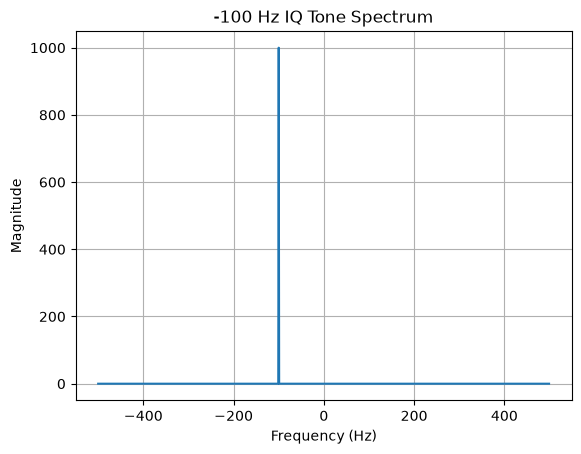

-100.0


In [9]:
_, iq_neg = generate_iq_tone(fs=1000, freq=-100, duration=1)
freqs, mag = magnitude_spectrum(iq_neg, 1000)

plt.plot(freqs, mag)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("-100 Hz IQ Tone Spectrum")
plt.grid()
plt.show()

print(freqs[np.argmax(mag)])

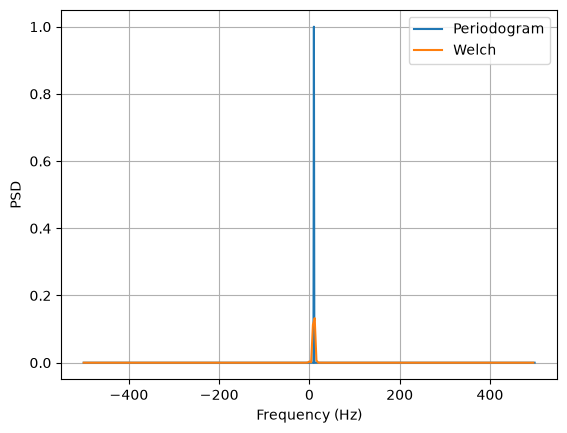

In [10]:
from iqwav.dsp import periodogram_psd, welch_psd

freq_p, psd_p = periodogram_psd(iq, fs)
freq_w, psd_w = welch_psd(iq, fs)

plt.plot(freq_p, psd_p, label="Periodogram")
plt.plot(freq_w, psd_w, label="Welch")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.grid()
plt.show()

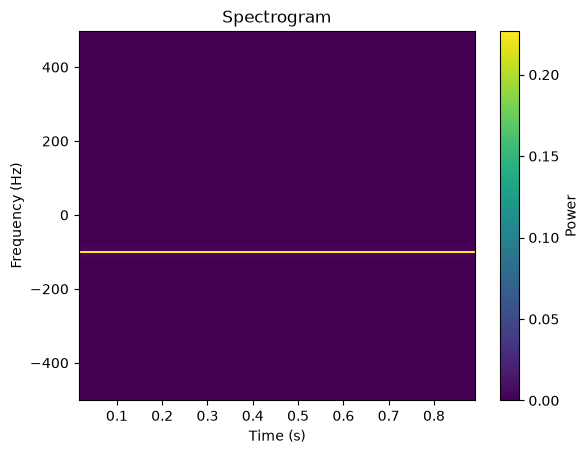

In [11]:
from iqwav.dsp import spectrogram_data

times, freqs, power = spectrogram_data(iq_neg, fs=1000, nperseg=250)

plt.pcolormesh(times, freqs, power, shading="auto")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram")
plt.colorbar(label="Power")
plt.show()

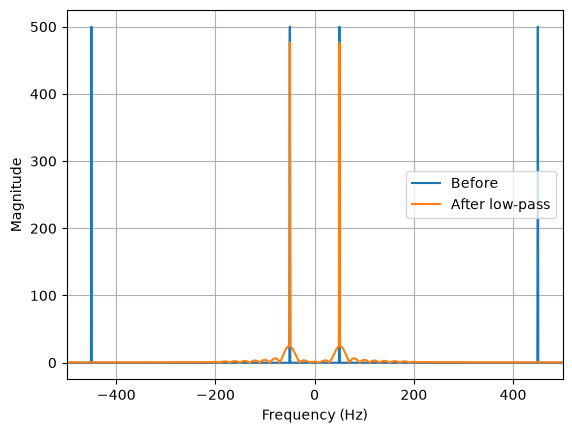

In [12]:
from iqwav.dsp import (
    design_lowpass_fir,
    design_highpass_fir,
    design_bandpass_fir,
    apply_fir_filter,
)

# Make a signal containing 50 Hz + 450 Hz
_, low = generate_real_tone(fs=1000, freq=50, duration=1)
_, high = generate_real_tone(fs=1000, freq=450, duration=1)

mixed = low + high

lp_taps = design_lowpass_fir(fs=1000, cutoff=200, numtaps=101)
filtered = apply_fir_filter(mixed, lp_taps)

# Compare spectra
f1, m1 = magnitude_spectrum(mixed, 1000)
f2, m2 = magnitude_spectrum(filtered, 1000)

plt.plot(f1, m1, label="Before")
plt.plot(f2, m2, label="After low-pass")
plt.xlim(-500, 500)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()
plt.show()

Clean power: 1.0
Noisy power: 1.0847648187959196


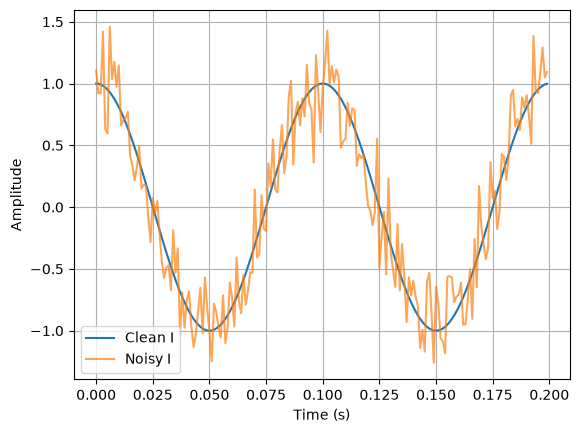

In [18]:
from iqwav.dsp import signal_power, add_awgn

clean = iq

noisy = add_awgn(clean, snr_db=10)

print("Clean power:", signal_power(clean))
print("Noisy power:", signal_power(noisy))

plt.plot(t[:200], clean.real[:200], label="Clean I")
plt.plot(t[:200], noisy.real[:200], label="Noisy I", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

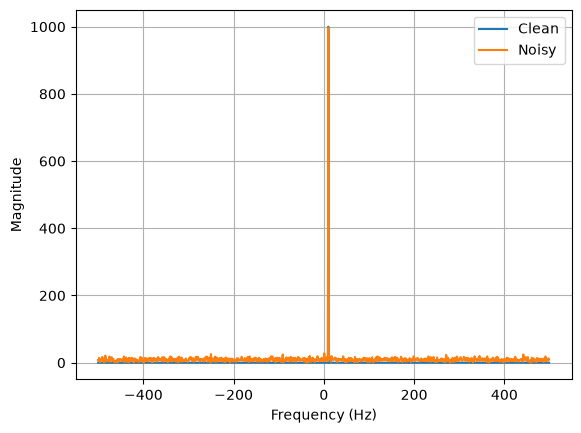

In [14]:
f_clean, m_clean = magnitude_spectrum(clean, fs)
f_noisy, m_noisy = magnitude_spectrum(noisy, fs)

plt.plot(f_clean, m_clean, label="Clean")
plt.plot(f_noisy, m_noisy, label="Noisy")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()
plt.show()